# Emergency Room Wait Time Analysis

## import libraries and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_csv("ER Wait Time Dataset.csv")

## Explore data

In [4]:
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [5]:
df.shape

(5000, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Visit ID                            5000 non-null   object
 1   Patient ID                          5000 non-null   object
 2   Hospital ID                         5000 non-null   object
 3   Hospital Name                       5000 non-null   object
 4   Region                              5000 non-null   object
 5   Visit Date                          5000 non-null   object
 6   Day of Week                         5000 non-null   object
 7   Season                              5000 non-null   object
 8   Time of Day                         5000 non-null   object
 9   Urgency Level                       5000 non-null   object
 10  Nurse-to-Patient Ratio              5000 non-null   int64 
 11  Specialist Availability             5000 non-null   int6

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Nurse-to-Patient Ratio,5000.0,3.2382,1.200895,1.0,3.0,3.0,4.0,5.0
Specialist Availability,5000.0,3.8750,3.043292,0.0,1.0,3.0,6.0,10.0
Facility Size (Beds),5000.0,87.1188,57.998585,10.0,36.0,74.0,138.0,200.0
Time to Registration (min),5000.0,11.7042,10.437284,0.0,3.0,8.0,18.0,66.0
Time to Triage (min),5000.0,24.8270,24.807994,1.0,6.0,16.0,36.0,163.0
Time to Medical Professional (min),5000.0,45.3854,35.619975,2.0,17.0,35.0,66.0,233.0
Total Wait Time (min),5000.0,81.9166,68.084538,4.0,27.0,60.0,122.0,442.0
Patient Satisfaction,5000.0,2.7716,1.424584,1.0,1.0,3.0,4.0,5.0


In [8]:
df.describe(include="object").T

,count,unique,top,freq
Visit ID,5000,5000,HOSP-1-20240210-0001,1
Patient ID,5000,5000,PAT-00001,1
Hospital ID,5000,5,HOSP-2,1023
Hospital Name,5000,5,Riverside Medical Center,1023
Region,5000,2,Urban,3006
Visit Date,5000,5000,2024-02-10 20:20:56,1
Day of Week,5000,7,Monday,768
Season,5000,4,Summer,1281
Time of Day,5000,5,Evening,1725
Urgency Level,5000,4,Medium,1291


In [9]:
# check for missing values
df.isnull().sum()

Visit ID                              0
Patient ID                            0
Hospital ID                           0
Hospital Name                         0
Region                                0
Visit Date                            0
Day of Week                           0
Season                                0
Time of Day                           0
Urgency Level                         0
Nurse-to-Patient Ratio                0
Specialist Availability               0
Facility Size (Beds)                  0
Time to Registration (min)            0
Time to Triage (min)                  0
Time to Medical Professional (min)    0
Total Wait Time (min)                 0
Patient Outcome                       0
Patient Satisfaction                  0
dtype: int64

In [10]:
df.columns

Index(['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region',
       'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level',
       'Nurse-to-Patient Ratio', 'Specialist Availability',
       'Facility Size (Beds)', 'Time to Registration (min)',
       'Time to Triage (min)', 'Time to Medical Professional (min)',
       'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction'],
      dtype='object')

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.duplicated(subset=["Patient ID","Hospital ID","Visit Date"]).sum()

np.int64(0)

### **Data Cleaning & Preprocessing Summary**

*   **Data Integrity:** Confirmed **zero missing values** and **no duplicate records**.
*   **Standardization:** Stripped whitespace from column headers and converted `Visit Date` to a **standardized datetime format**.
*   **Wait Time Validation:** Verified that `Total Wait Time` logically aligns with the sum of its individual phases (Registration, Triage, and Professional Contact).
*   **Outlier Strategy:** High-variance **Wait Time** data points were **deliberately retained**. These reflect authentic peak-demand scenarios and provide critical insight into "worst-case" operational stress.

In [13]:
# edit the columns name 
df.columns =df.columns.str.strip()

In [14]:
# change the type of date column
df['Visit Date'] = pd.to_datetime(df['Visit Date'])

In [15]:
# make new columns that show the hour and month
df['Hour'] = df['Visit Date'].dt.hour
df['Month'] = df['Visit Date'].dt.month

In [16]:
month_map = {
    1: 'January', 2: 'February', 3: 'March',
    4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September',
    10: 'October', 11: 'November', 12: 'December'
}
df['Month'] = df['Month'].map(month_map)

In [17]:
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,...,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction,Hour,Month
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,...,3,92,17,22,66,105,Discharged,1,20,February
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,...,0,38,9,30,30,69,Discharged,3,2,November
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,...,1,38,38,40,125,203,Discharged,1,4,September
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,...,5,94,8,16,64,88,Discharged,2,0,February
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,...,8,74,26,29,63,118,Discharged,1,16,March


In [18]:
df['Total'] = df['Time to Registration (min)'] +df['Time to Triage (min)'] + df['Time to Medical Professional (min)']

print((df['Total'] != df['Total Wait Time (min)']).sum())

0


all the values in 'Total Wait Time (min)' are correct

In [19]:
df.drop(columns='Total',inplace=True)
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,...,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction,Hour,Month
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,...,3,92,17,22,66,105,Discharged,1,20,February
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,...,0,38,9,30,30,69,Discharged,3,2,November
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,...,1,38,38,40,125,203,Discharged,1,4,September
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,...,5,94,8,16,64,88,Discharged,2,0,February
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,...,8,74,26,29,63,118,Discharged,1,16,March


## EDA

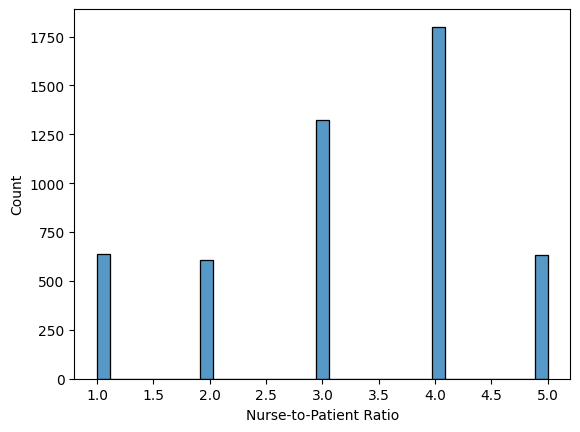

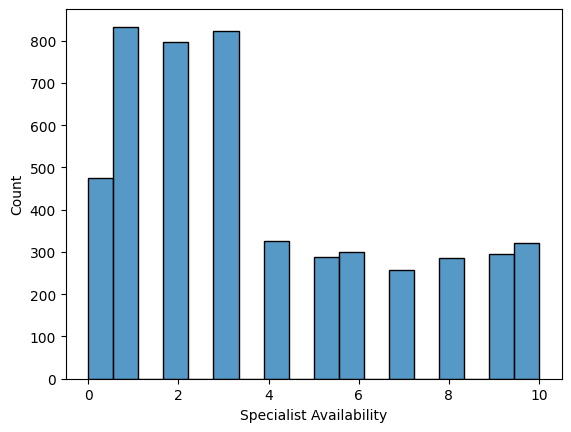

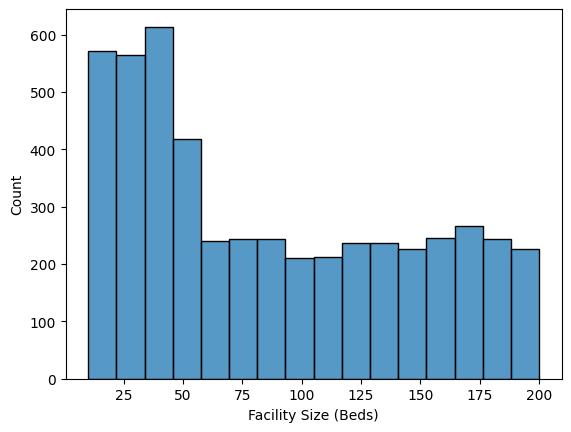

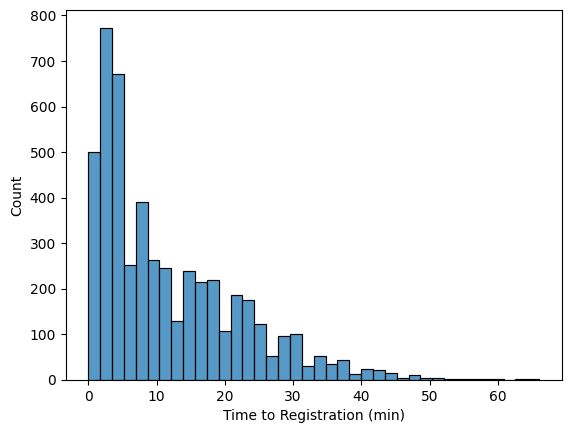

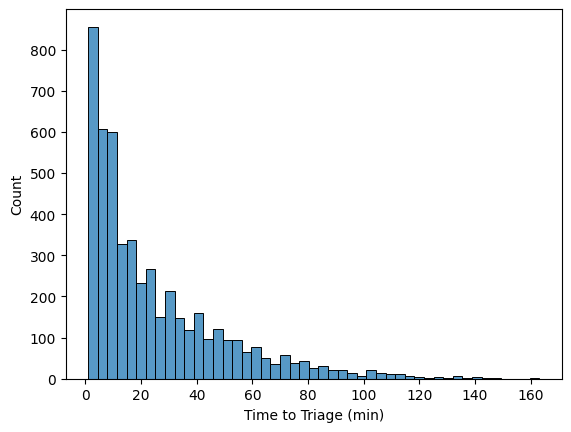

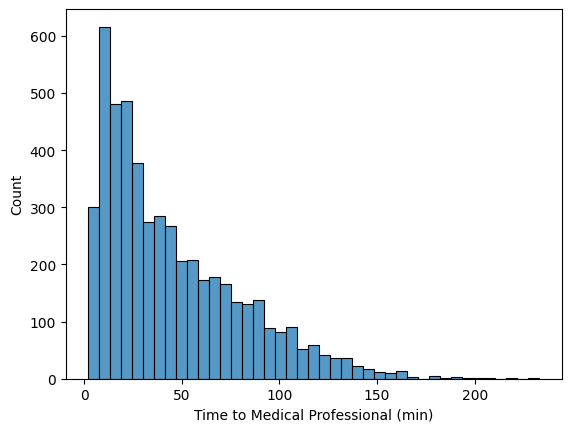

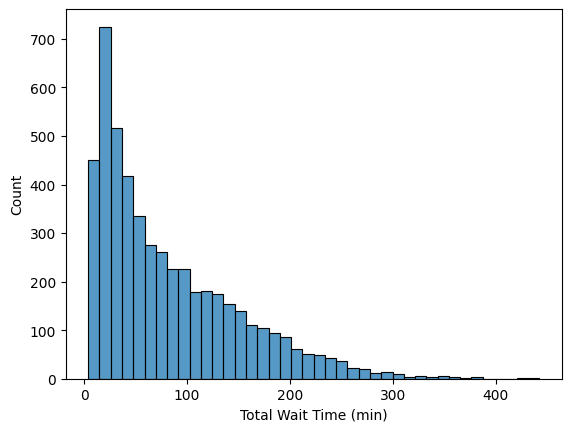

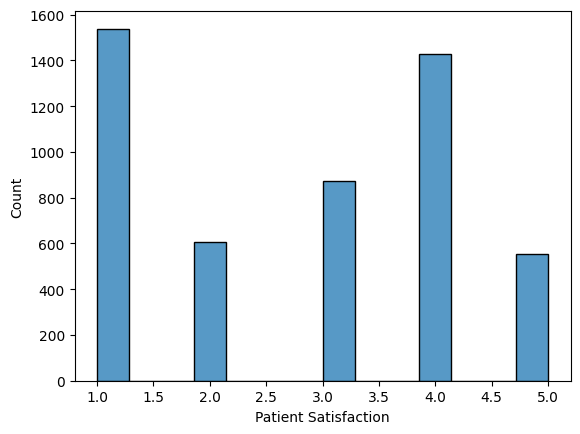

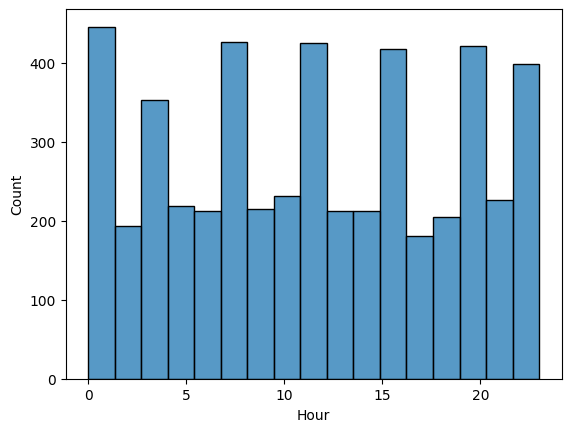

In [20]:
# distribution analysis using histplots
for i in df.select_dtypes(include='number').columns:
    sns.histplot(data=df,x=i) 
    plt.show()

## Distributional Analysis and Strategic Recommendations

### 1. Clinical Staffing and Infrastructure
* **Nurse-to-Patient Ratio:** Data indicates a robust staffing density, with the majority of visits occurring in environments maintaining a ratio between **3.0 and 4.0**. This suggests a strong baseline for bedside care availability in a significant portion of the sampled facilities.
* **Specialist Availability:** A critical resource gap is evident here. Most visits are characterized by low specialist presence (typically **1 to 2 specialists**). To mitigate clinical bottlenecks and enhance specialized care delivery, a strategic increase in specialist recruitment or on-call rotation is recommended.
* **Facility Capacity (Beds):** The distribution shows a skew toward lower bed counts during the majority of recorded visits. This limited physical capacity may act as a primary constraint on longitudinal medical treatment and inpatient admissions.

### 2. Patient Throughput and Temporal Trends
* **Wait Time Volatility:** While the median distribution for registration and triage suggests "normal" or standard wait times, there is a significant **right-tail distribution** representing a high volume of facilities with excessive delays.
* **The Medical Professional Bottleneck:** Analysis identifies the **"Time to Medical Professional"** phase as the primary contributor to total patient stay length. This phase requires targeted process improvement to reduce the duration between triage and definitive provider contact.
* **Temporal Uniformity:** The distribution of visits across various **Hours** is remarkably uniform. This suggests that the identified inefficiencies are systemic rather than seasonal or time-of-day dependent, requiring a structural rather than a shift-based solution.

### 3. Patient Experience Outcomes
* **Satisfaction Levels:** The data reveals a concerning distribution of **Patient Satisfaction** scores, with a high frequency of suboptimal ratings. Given the strong negative correlation between wait times and satisfaction, addressing the medical professional bottleneck is the most viable path to improving these metrics.

---

### Key Performance Indicators (KPI) Summary

| Metric | Current Status | Strategic Priority |
| :--- | :--- | :--- |
| **Nurse-to-Patient Ratio** | Stable (3.0 - 4.0) | Maintain current standards |
| **Specialist Availability** | Critical Deficiency | Increase headcount/availability |
| **Medical Professional Contact** | High Latency | Streamline provider hand-off |
| **Patient Satisfaction** | Low | Implement wait-time reduction |

**Would you like me to generate a summary of specific action items based on these distribution insights?**

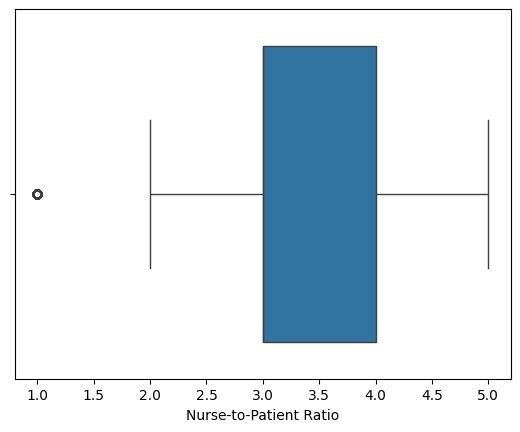

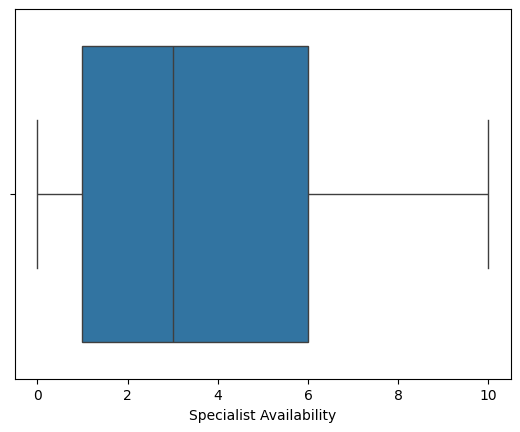

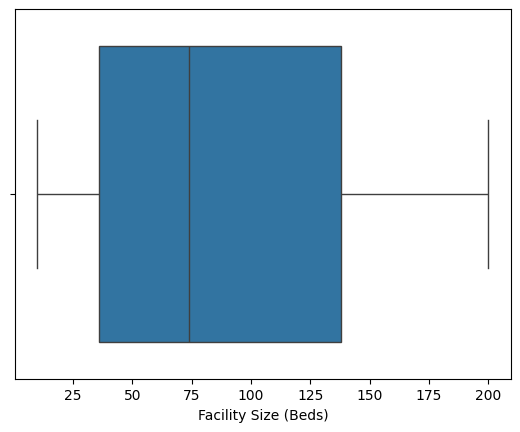

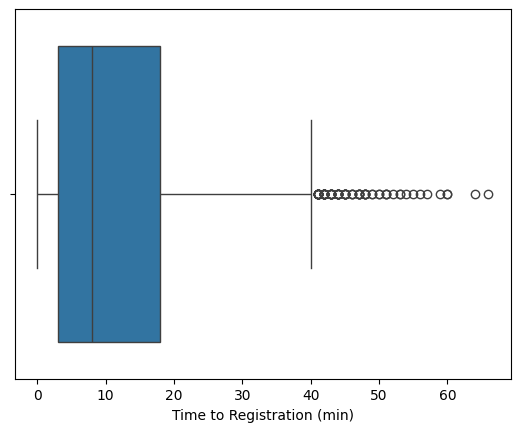

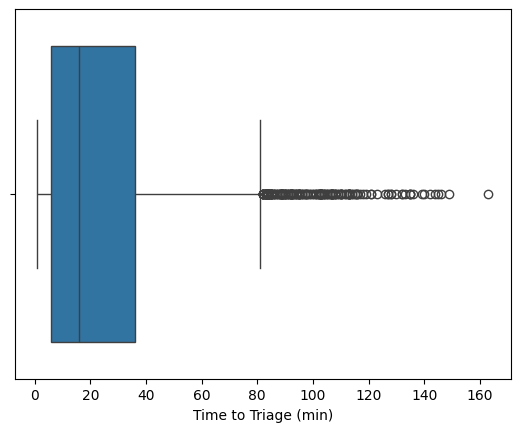

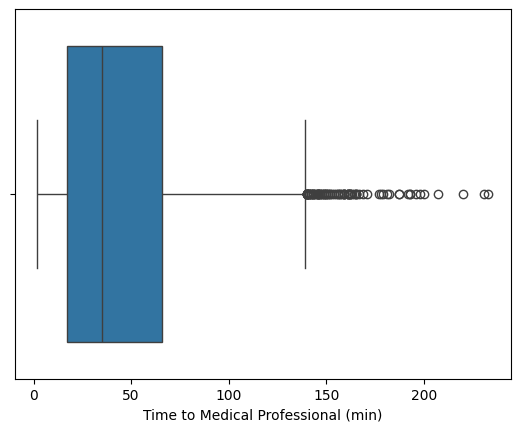

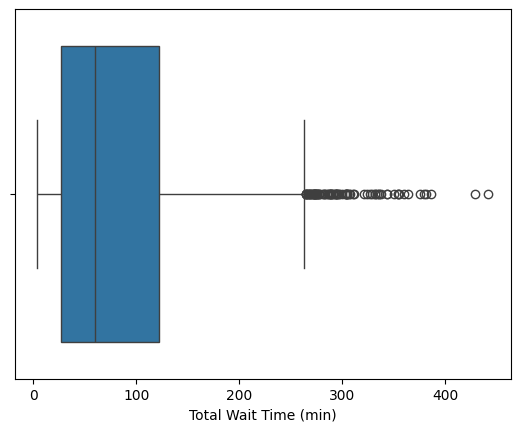

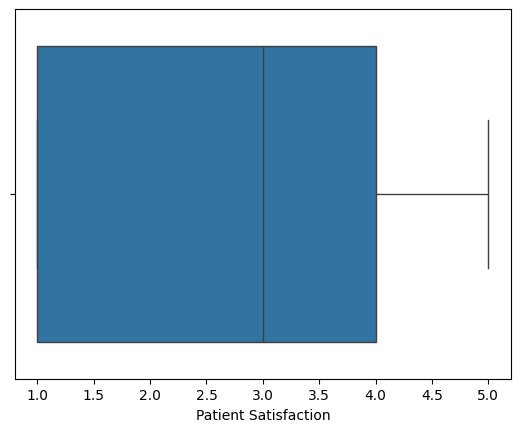

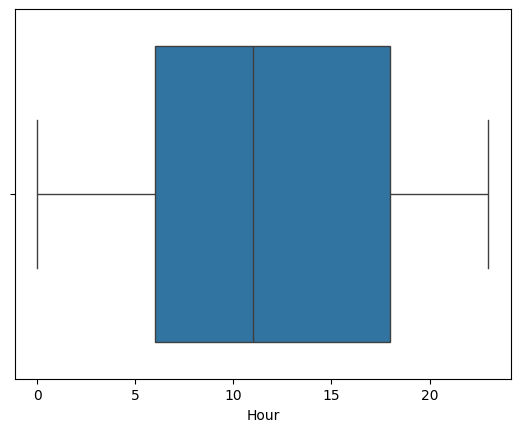

In [21]:
## check outliers
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.show()

## Data Integrity and Outlier Analysis

An evaluation of the dataset's distribution reveals that the majority of operational variables remain within expected statistical parameters. However, the **Waiting Time** metrics exhibit a degree of variance, with several data points qualifying as outliers.

Upon further review, these observations will be **retained in the primary analysis** for the following reasons:

*   **Proximity to Thresholds:** The identified outliers do not deviate significantly from the established upper caps, suggesting they represent genuine, albeit high, operational occurrences rather than data entry errors.
*   **Contextual Relevance:** In a clinical environment, extreme wait times are often authentic reflections of peak demand or complex triage scenarios. Removing them would artificially sanitize the data and mask critical "worst-case" performance realities.
*   **Statistical Impact:** The range of these outliers is sufficiently narrow that they are unlikely to disproportionately skew the correlation coefficients or lead to a misrepresentation of the broader trends.


<Axes: >

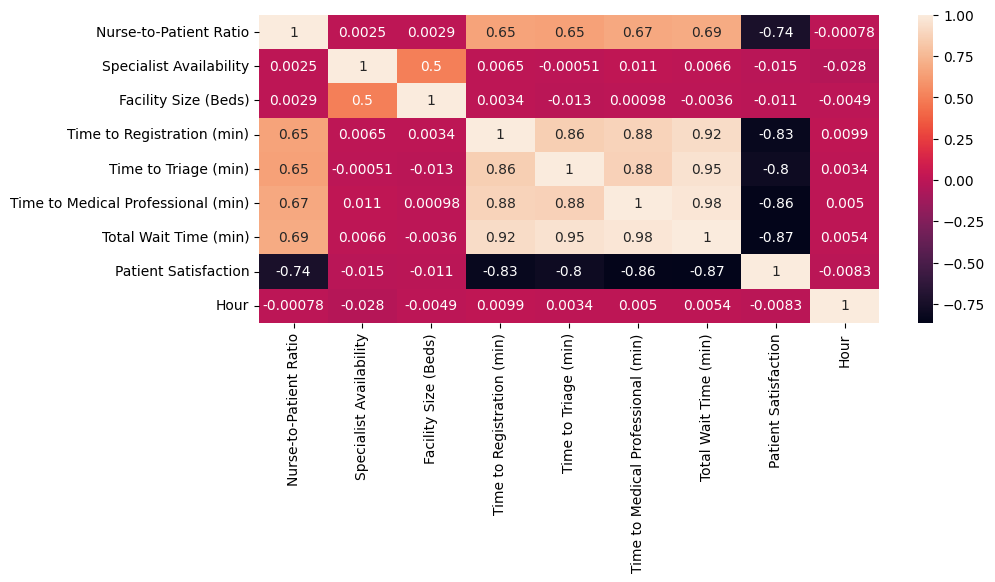

In [22]:
## check correlations
s =df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,4))  
sns.heatmap(s,annot=True)

### 1. The "Wait Time" Cluster
There is an **extremely strong positive correlation** (ranging from **0.86 to 0.98**) between all time-based metrics:
* **Total Wait Time** is almost perfectly correlated with **Time to Medical Professional (0.98)** and **Time to Triage (0.95)**.
* This suggests that a delay in one part of the patient journey (like registration) almost inevitably leads to a cascade of delays throughout the entire visit.

### 2. Impact on Patient Satisfaction
Patient Satisfaction has a **strong negative correlation** with almost every time-related metric:
* **Total Wait Time (-0.87)** and **Time to Medical Professional (-0.86)** are the biggest drivers of dissatisfaction.
* Interestingly, the **Nurse-to-Patient Ratio** also has a significant negative correlation (**-0.74**) with satisfaction. This implies that as the number of patients per nurse increases (higher ratio), satisfaction drops sharply.

### 3. Staffing vs. Efficiency
* **Nurse-to-Patient Ratio:** As this ratio increases (fewer nurses per patient), wait times increase (correlation of **~0.65 to 0.69**). This confirms that staffing levels are a direct bottleneck for patient flow.
* **Specialist Availability:** Surprisingly, specialist availability and facility size (beds) show **almost zero correlation** with wait times or patient satisfaction. This suggests that "more space" or "more specialists" doesn't necessarily solve the immediate flow issues if nursing staff levels aren't optimized.

### 4. Temporal Trends
* The **"Hour"** variable shows near-zero correlation with every other metric. This indicates that the efficiency issues and satisfaction levels are likely consistent throughout the day, rather than being spikes caused by a specific "rush hour."

---

### Summary Table: Key Drivers
| Driver | Impact on Satisfaction | Strength |
| :--- | :--- | :--- |
| **Total Wait Time** | Decreases Satisfaction | Very Strong (-0.87) |
| **Nurse-to-Patient Ratio** | Decreases Satisfaction | Strong (-0.74) |
| **Facility Size** | No Impact | Negligible (-0.01) |


In [23]:
df.columns

Index(['Visit ID', 'Patient ID', 'Hospital ID', 'Hospital Name', 'Region',
       'Visit Date', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level',
       'Nurse-to-Patient Ratio', 'Specialist Availability',
       'Facility Size (Beds)', 'Time to Registration (min)',
       'Time to Triage (min)', 'Time to Medical Professional (min)',
       'Total Wait Time (min)', 'Patient Outcome', 'Patient Satisfaction',
       'Hour', 'Month'],
      dtype='object')

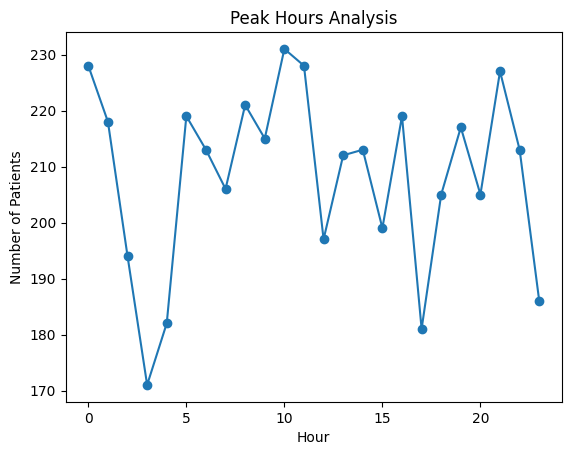

In [24]:
hourly_visits = df.groupby('Hour').size()

plt.figure()
hourly_visits.plot(kind='line',marker = 'o')
plt.xlabel('Hour')
plt.ylabel('Number of Patients')
plt.title('Peak Hours Analysis')
plt.show()

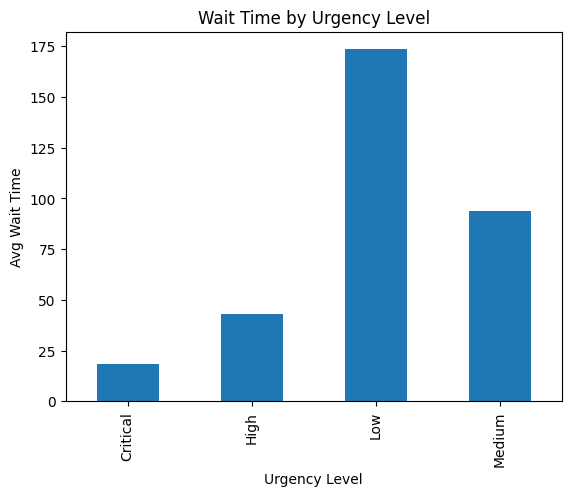

In [25]:
urgency_wait = df.groupby('Urgency Level')['Total Wait Time (min)'].mean()

plt.figure()
urgency_wait.plot(kind='bar')
plt.xlabel('Urgency Level')
plt.ylabel('Avg Wait Time')
plt.title('Wait Time by Urgency Level')
plt.show()

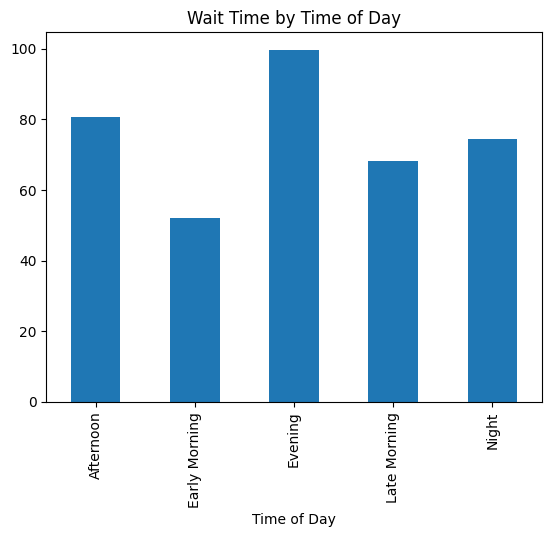

In [26]:
time_wait = df.groupby('Time of Day')['Total Wait Time (min)'].mean()

plt.figure()
time_wait.plot(kind='bar')
plt.title('Wait Time by Time of Day')
plt.show()

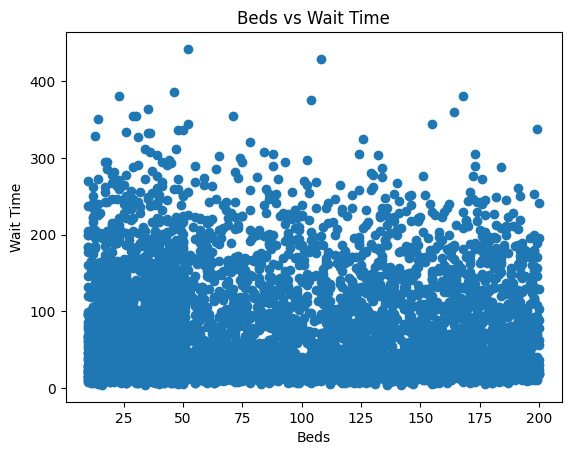

In [27]:
plt.figure()
plt.scatter(df['Facility Size (Beds)'], df['Total Wait Time (min)'])
plt.xlabel('Beds')
plt.ylabel('Wait Time')
plt.title('Beds vs Wait Time')
plt.show()

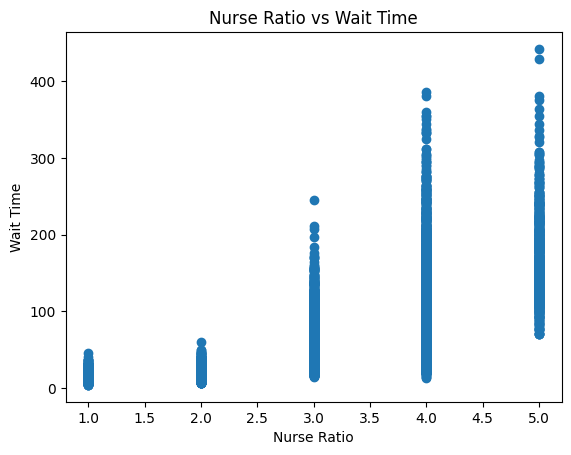

In [28]:
plt.figure()
plt.scatter(df['Nurse-to-Patient Ratio'], df['Total Wait Time (min)'])
plt.xlabel('Nurse Ratio')
plt.ylabel('Wait Time')
plt.title('Nurse Ratio vs Wait Time')
plt.show()

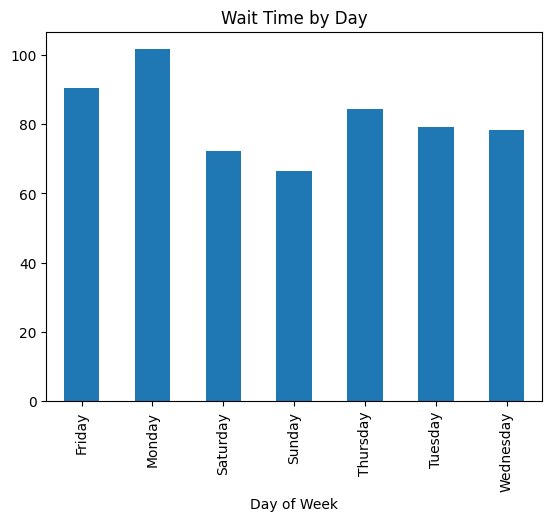

In [29]:
week_wait = df.groupby('Day of Week')['Total Wait Time (min)'].mean()

plt.figure()
week_wait.plot(kind='bar')
plt.title('Wait Time by Day')
plt.show()

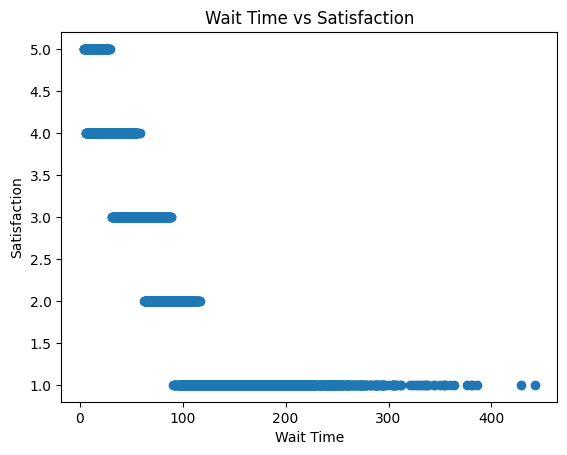

In [30]:
plt.figure()
plt.scatter(df['Total Wait Time (min)'], df['Patient Satisfaction'])
plt.xlabel('Wait Time')
plt.ylabel('Satisfaction')
plt.title('Wait Time vs Satisfaction')
plt.show()

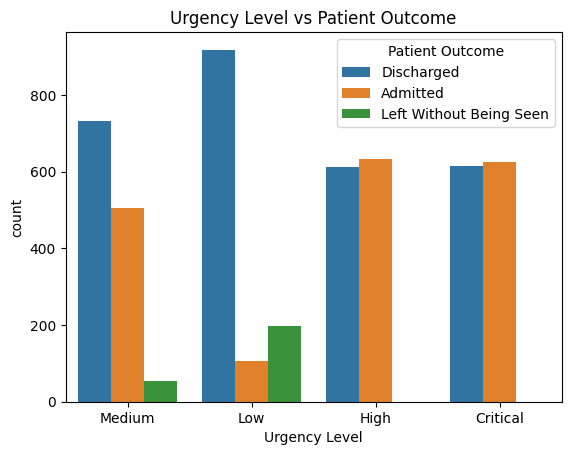

In [31]:
sns.countplot(data=df, x='Urgency Level', hue='Patient Outcome')
plt.title("Urgency Level vs Patient Outcome")
plt.show()

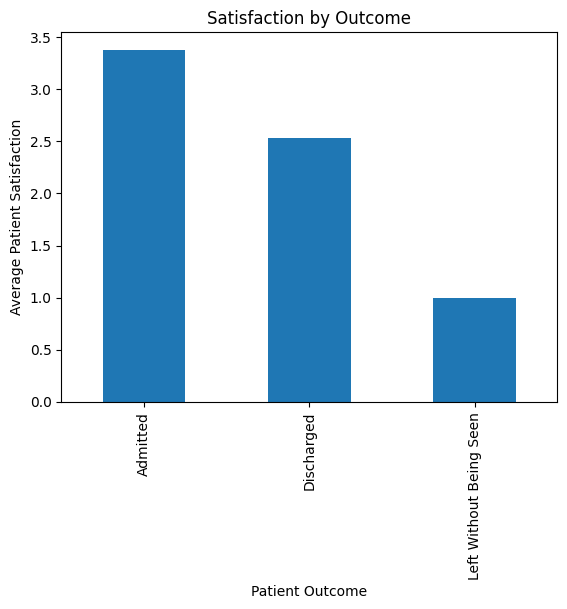

In [32]:
df.groupby('Patient Outcome')['Patient Satisfaction'].mean().plot(kind='bar', title='Satisfaction by Outcome')
plt.xlabel('Patient Outcome')        
plt.ylabel('Average Patient Satisfaction')  
plt.show()

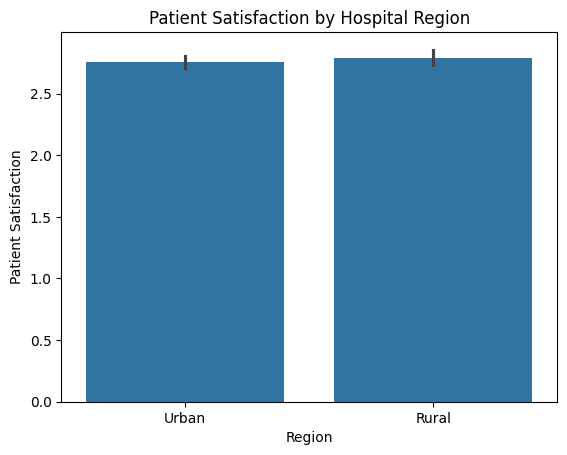

In [33]:
sns.barplot(x='Region', y='Patient Satisfaction', data=df)
plt.title("Patient Satisfaction by Hospital Region")
plt.show()

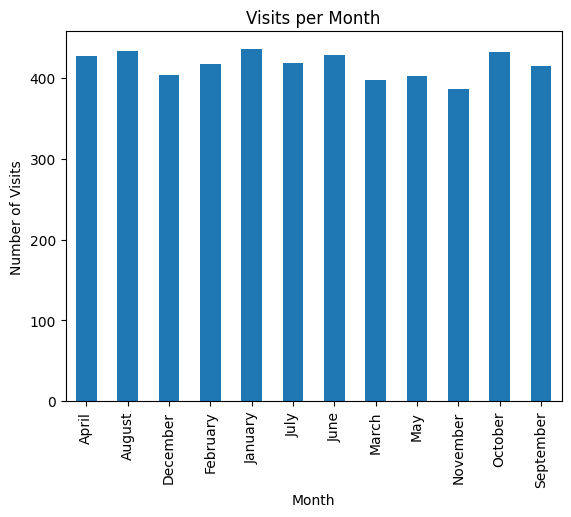

In [34]:
df['Month'].value_counts().sort_index().plot(kind='bar', title='Visits per Month')
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.show()

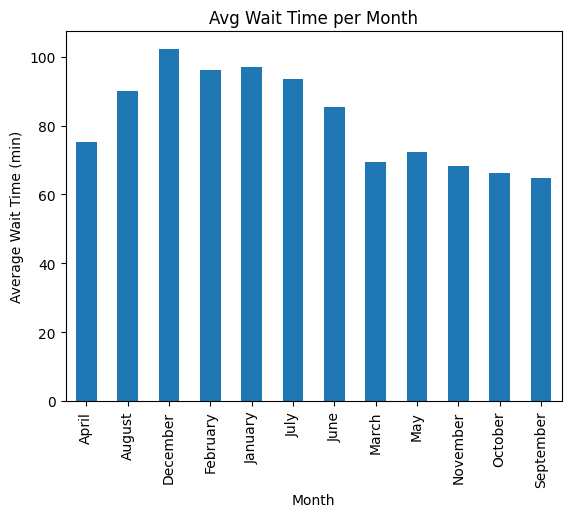

In [35]:
df.groupby('Month')['Total Wait Time (min)'].mean().plot(kind='bar', title='Avg Wait Time per Month')
plt.xlabel('Month')
plt.ylabel('Average Wait Time (min)')
plt.show()

In [36]:
df.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,...,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction,Hour,Month
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,...,3,92,17,22,66,105,Discharged,1,20,February
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,...,0,38,9,30,30,69,Discharged,3,2,November
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,...,1,38,38,40,125,203,Discharged,1,4,September
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,...,5,94,8,16,64,88,Discharged,2,0,February
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,...,8,74,26,29,63,118,Discharged,1,16,March


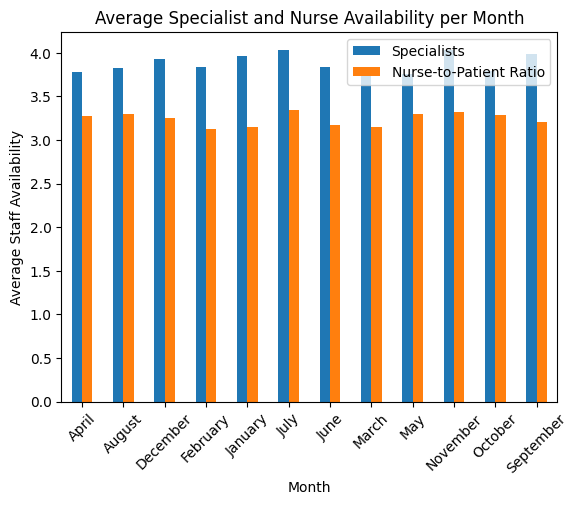

In [37]:
monthly_staff = df.groupby('Month')[['Specialist Availability', 'Nurse-to-Patient Ratio']].mean()

monthly_staff.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average Staff Availability')
plt.title('Average Specialist and Nurse Availability per Month')
plt.xticks(rotation=45)
plt.legend(['Specialists', 'Nurse-to-Patient Ratio'])
plt.show()

In [38]:
# save the data
df.to_csv("ER_Wait_time_edited.csv", index=False)